# Sintesi comparativa dei modelli — target CAMS e target ARPA

Questo notebook **non ristima nulla**: legge i risultati già prodotti da

- `modello_s5p_era5_cams.ipynb` → `risultati_modello/`
- `modello_s5p_era5_arpa.ipynb` → `risultati_modello_arpa/`

e li presenta in **due tabelle omogenee** — stessa struttura, stesse colonne, stesso ordine —
così che il confronto fra le due famiglie di modelli sia diretto.

Per ogni inquinante vengono riportati: **target**, **predittori selezionati**, **lag**,
**media mobile**, **tipo di modello**, **equazione**, **coefficienti**, **R² di validazione**,
**RMSE**, **MAE**, **bias** e **numero di osservazioni**.

> **Prerequisito.** Entrambi i notebook dei modelli devono essere stati eseguiti almeno una
> volta. Se una delle due cartelle manca, il notebook segnala l'assenza e prosegue con quella
> disponibile.

## 1. Caricamento dei risultati

Le due pipeline scrivono file con **nomi e schema identici**, quindi la lettura è la stessa
funzione applicata a due cartelle diverse. Questa simmetria è ciò che rende le tabelle
confrontabili riga per riga.

| File letto | Contenuto usato |
|---|---|
| `modello_sintesi.csv` | R² validato, RMSE, MAE, bias, media del target |
| `modello_coefficienti.csv` | coefficienti, errori standard, p-value, β standardizzati |
| `modello_equazioni.csv` | n usato per la stima finale, R² in-sample |
| `modello_disponibilita_dati.csv` | righe complete, punti, giorni |
| `modello_metriche_per_fold.csv` | dispersione dell'R² fra i blocchi di test |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Math

plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_colwidth', None)

CARTELLE = {
    'CAMS': Path('risultati_modello'),
    'ARPA': Path('risultati_modello_arpa'),
}
OUT_DIR = Path('risultati_sintesi')
OUT_DIR.mkdir(exist_ok=True)

ORDINE = ['NO2', 'O3', 'PM10', 'PM25']
ETICHETTA_INQ = {'NO2': 'NO₂', 'O3': 'O₃', 'PM10': 'PM10', 'PM25': 'PM2.5'}

# Simboli leggibili per i predittori
SIMBOLI = {
    'era5_ssrd_MJ': 'SSRD', 'inv_blh': '1/BLH', 'era5_t2m_C': 'T2m',
    'era5_tp_mm': 'TP', 'vento_velocita': 'WS', 'const': 'intercetta',
}
UNITA = {
    'era5_ssrd_MJ': 'MJ/m²', 'inv_blh': '1/m', 'era5_t2m_C': '°C',
    'era5_tp_mm': 'mm', 'vento_velocita': 'm/s',
}
TIPO_MODELLO = ('Regressione lineare multipla (OLS, statsmodels)\n'
                'unità originali · nessuna regolarizzazione · 6 predittori')

FILE_ATTESI = ['modello_sintesi.csv', 'modello_coefficienti.csv',
               'modello_equazioni.csv', 'modello_disponibilita_dati.csv',
               'modello_metriche_per_fold.csv']


def carica(cartella):
    # Legge i CSV di una pipeline; restituisce None se la cartella non è utilizzabile.
    if not cartella.exists():
        print(f'[{cartella}] cartella assente: eseguire prima il notebook corrispondente.')
        return None
    mancanti = [f for f in FILE_ATTESI if not (cartella / f).exists()]
    if mancanti:
        print(f'[{cartella}] file mancanti: {mancanti}')
        return None
    d = {f.replace('modello_', '').replace('.csv', ''):
         pd.read_csv(cartella / f, sep=';', decimal=',') for f in FILE_ATTESI}
    print(f'[{cartella}] caricati {len(d)} file — inquinanti: '
          f"{list(d['sintesi']['Inquinante'])}")
    return d


RIS = {k: carica(v) for k, v in CARTELLE.items()}
DISPONIBILI = [k for k, v in RIS.items() if v is not None]
print('\nFamiglie di modelli disponibili:', DISPONIBILI)

[risultati_modello] caricati 5 file — inquinanti: ['NO2', 'O3', 'PM10', 'PM25']
[risultati_modello_arpa] caricati 5 file — inquinanti: ['NO2', 'O3', 'PM10', 'PM25']

Famiglie di modelli disponibili: ['CAMS', 'ARPA']


## 2. Costruzione tabelle omogenee

Le colonne sono definite **una volta sola** e riusate per entrambe le famiglie: qualsiasi
differenza fra le due tabelle è quindi una differenza nei risultati, non nella presentazione.

Sul **numero di osservazioni** vengono riportate due grandezze distinte, perché rispondono a
domande diverse:

- **n stima** — righe usate per stimare il modello finale (casi completi su tutto il 2025);
- **n validazione** — righe effettivamente previste **fuori campione** nei blocchi di test.
  È su queste che sono calcolati R², RMSE, MAE e bias riportati in tabella.

In [2]:
def formatta(v, dec=3):
    # Notazione compatta: scientifica per ordini di grandezza estremi, decimale altrimenti.
    if v is None or (isinstance(v, float) and not np.isfinite(v)):
        return 'n/d'
    if v != 0 and (abs(v) >= 1e4 or abs(v) < 1e-3):
        return f'{v:.3e}'
    return f'{v:.{dec}f}'


def nome_s5p(pred, con_finestra=True):
    # Da 's5p_no2_lag7_ma14' a 'S5P NO2 (t−7, MA14)'
    m = re.match(r's5p_(\w+?)_lag(\d+)_ma(\d+)$', pred)
    if not m:
        return pred
    specie, lag, ma = m.group(1).upper(), int(m.group(2)), int(m.group(3))
    if not con_finestra:
        return f'S5P {specie}'
    quando = 't' if lag == 0 else f't−{lag}'
    return f'S5P {specie} ({quando}, MA{ma})'


def estrai_lag_ma(pred):
    m = re.match(r's5p_\w+?_lag(\d+)_ma(\d+)$', pred)
    return (int(m.group(1)), int(m.group(2))) if m else (np.nan, np.nan)


def simbolo(pred):
    return SIMBOLI.get(pred, nome_s5p(pred))


def costruisci_tabella(dati, famiglia):
    righe = []
    for inq in ORDINE:
        sin = dati['sintesi'].set_index('Inquinante').loc[inq]
        equ = dati['equazioni'].set_index('Inquinante').loc[inq]
        dis = dati['disponibilita_dati'].set_index('Inquinante').loc[inq]
        cf = dati['coefficienti']
        cf = cf[cf['Inquinante'] == inq]

        riga_s5p = cf[cf['famiglia'] == 'Sentinel-5P'].iloc[0]
        pred_s5p = riga_s5p['predittore']
        lag, ma = estrai_lag_ma(pred_s5p)
        pred_era5 = cf[cf['famiglia'] == 'ERA5']['predittore'].tolist()

        # target: dal nome della colonna nell'equazione salvata (es. 'cams_no2_stim = ...')
        target = equ['equazione'].split('_stim')[0].strip()

        # equazione leggibile
        intercetta = float(cf[cf['predittore'] == 'const']['coef'].iloc[0])
        termini = [formatta(intercetta)]
        for _, r in cf[cf['predittore'] != 'const'].iterrows():
            segno = '+' if r['coef'] >= 0 else '−'
            termini.append(f"{segno} {formatta(abs(r['coef']))}·{simbolo(r['predittore'])}")
        equazione = f"{ETICHETTA_INQ[inq]} = " + ' '.join(termini)

        # coefficienti con beta standardizzato
        voci = []
        for _, r in cf[cf['predittore'] != 'const'].iterrows():
            voci.append(f"{simbolo(r['predittore'])}: {formatta(r['coef'])} "
                        f"(β={r['beta_std']:+.3f}, p={r['p_value']:.1e})")
        voci.append(f"intercetta: {formatta(intercetta)}")
        coefficienti = '\n'.join(voci)

        r2_fold = dati['metriche_per_fold']
        r2_fold = r2_fold[r2_fold['Inquinante'] == inq]['R2']

        righe.append({
            'Inquinante': ETICHETTA_INQ[inq],
            'Target': target,
            'Predittori selezionati': (f'{nome_s5p(pred_s5p, False)}  [Sentinel-5P]\n'
                                       + ', '.join(SIMBOLI[p] for p in pred_era5)
                                       + '  [ERA5, giorno t]'),
            'Lag S5P [gg]': lag,
            'MA S5P [gg]': ma,
            'Tipo di modello': TIPO_MODELLO,
            'Equazione': equazione,
            'Coefficienti': coefficienti,
            'R² validazione': round(float(sin['R² validato (aggregato)']), 3),
            'R² medio per fold': round(float(r2_fold.mean()), 3),
            'RMSE': round(float(sin['RMSE']), 3),
            'MAE': round(float(sin['MAE']), 3),
            'Bias': round(float(sin['Bias']), 3),
            'n stima': int(equ['n']),
            'n validazione': int(sin['n']),
            'media target': round(float(sin['media target']), 2),
            'RMSE / media [%]': round(float(sin['RMSE / media [%]']), 1),
        })
    return pd.DataFrame(righe)


TABELLE = {f: costruisci_tabella(RIS[f], f) for f in DISPONIBILI}
COLONNE = list(TABELLE[DISPONIBILI[0]].columns)
print('Colonne (identiche per entrambe le tabelle):')
for c in COLONNE:
    print('  -', c)

Colonne (identiche per entrambe le tabelle):
  - Inquinante
  - Target
  - Predittori selezionati
  - Lag S5P [gg]
  - MA S5P [gg]
  - Tipo di modello
  - Equazione
  - Coefficienti
  - R² validazione
  - R² medio per fold
  - RMSE
  - MAE
  - Bias
  - n stima
  - n validazione
  - media target
  - RMSE / media [%]


In [3]:
# ── Stile condiviso: le due tabelle devono avere esattamente lo stesso aspetto ──
STILE = [
    {'selector': 'th.col_heading',
     'props': [('background-color', '#1F7A8C'), ('color', 'white'),
               ('font-weight', 'bold'), ('text-align', 'left'),
               ('padding', '7px 12px'), ('border', '2px solid white'),
               ('vertical-align', 'top')]},
    {'selector': 'th.row_heading',
     'props': [('background-color', '#1F7A8C'), ('color', 'white'),
               ('font-weight', 'bold'), ('text-align', 'left'),
               ('padding', '7px 12px'), ('border', '2px solid white'),
               ('white-space', 'nowrap'), ('vertical-align', 'top')]},
    {'selector': 'td',
     'props': [('background-color', '#EDEDED'), ('color', '#222222'),
               ('white-space', 'pre-wrap'), ('padding', '7px 12px'),
               ('border', '2px solid white'), ('font-size', '12px'),
               ('text-align', 'left'), ('vertical-align', 'top')]},
]


def mostra(tab, titolo):
    # Vista trasposta: inquinanti in colonna, campi in riga. Con 4 inquinanti e 17 campi
    # è l'unico orientamento che resta leggibile senza scorrimento orizzontale.
    t = tab.set_index('Inquinante').T
    t.columns.name = None
    display(Markdown(f'**{titolo}**'))
    display(t.style.set_table_styles(STILE))
    return t

## 3. Tabella A — modelli con target CAMS

In [4]:
if 'CAMS' in TABELLE:
    T_CAMS = mostra(TABELLE['CAMS'], 'Modelli a target CAMS — sintesi completa')
    TABELLE['CAMS'].to_csv(OUT_DIR / 'tabella_modelli_cams.csv',
                           sep=';', decimal=',', index=False)
else:
    print('Risultati CAMS non disponibili.')

**Modelli a target CAMS — sintesi completa**

,NO₂,O₃,PM10,PM2.5
Target,cams_no2,cams_o3,cams_pm10,cams_pm25
Predittori selezionati,"S5P NO2 [Sentinel-5P] SSRD, 1/BLH, T2m, TP, WS [ERA5, giorno t]","S5P NO2 [Sentinel-5P] SSRD, 1/BLH, T2m, TP, WS [ERA5, giorno t]","S5P PM10 [Sentinel-5P] SSRD, 1/BLH, T2m, TP, WS [ERA5, giorno t]","S5P NO2 [Sentinel-5P] SSRD, 1/BLH, T2m, TP, WS [ERA5, giorno t]"
Lag S5P [gg],7,0,3,7
MA S5P [gg],14,14,14,14
Tipo di modello,"Regressione lineare multipla (OLS, statsmodels) unità originali · nessuna regolarizzazione · 6 predittori","Regressione lineare multipla (OLS, statsmodels) unità originali · nessuna regolarizzazione · 6 predittori","Regressione lineare multipla (OLS, statsmodels) unità originali · nessuna regolarizzazione · 6 predittori","Regressione lineare multipla (OLS, statsmodels) unità originali · nessuna regolarizzazione · 6 predittori"
Equazione,"NO₂ = 3.859 + 9.131e+04·S5P NO2 (t−7, MA14) − 1.511·SSRD + 10.365·1/BLH + 0.280·T2m − 0.689·TP − 0.515·WS","O₃ = 38.206 − 1.268e+05·S5P NO2 (t, MA14) + 12.293·SSRD + 12.301·1/BLH + 0.153·T2m + 1.853·TP + 1.099·WS","PM10 = 34.002 + 14.746·S5P PM10 (t−3, MA14) − 3.447·SSRD + 3.175·1/BLH + 0.422·T2m − 2.319·TP − 1.788·WS","PM2.5 = 5.035 + 1.047e+05·S5P NO2 (t−7, MA14) − 1.065·SSRD − 20.704·1/BLH + 0.297·T2m − 1.198·TP − 1.792·WS"
Coefficienti,"S5P NO2 (t−7, MA14): 9.131e+04 (β=+0.800, p=0.0e+00) SSRD: -1.511 (β=-0.185, p=0.0e+00) 1/BLH: 10.365 (β=+0.008, p=1.2e-15) T2m: 0.280 (β=+0.241, p=0.0e+00) TP: -0.689 (β=-0.101, p=0.0e+00) WS: -0.515 (β=-0.040, p=0.0e+00) intercetta: 3.859","S5P NO2 (t, MA14): -1.268e+05 (β=-0.410, p=0.0e+00) SSRD: 12.293 (β=+0.549, p=0.0e+00) 1/BLH: 12.301 (β=+0.004, p=5.9e-05) T2m: 0.153 (β=+0.049, p=0.0e+00) TP: 1.853 (β=+0.101, p=0.0e+00) WS: 1.099 (β=+0.031, p=0.0e+00) intercetta: 38.206","S5P PM10 (t−3, MA14): 14.746 (β=+0.367, p=0.0e+00) SSRD: -3.447 (β=-0.299, p=0.0e+00) 1/BLH: 3.175 (β=+0.002, p=2.6e-01) T2m: 0.422 (β=+0.264, p=0.0e+00) TP: -2.319 (β=-0.239, p=0.0e+00) WS: -1.788 (β=-0.097, p=0.0e+00) intercetta: 34.002","S5P NO2 (t−7, MA14): 1.047e+05 (β=+0.723, p=0.0e+00) SSRD: -1.065 (β=-0.103, p=0.0e+00) 1/BLH: -20.704 (β=-0.013, p=2.3e-24) T2m: 0.297 (β=+0.202, p=0.0e+00) TP: -1.198 (β=-0.138, p=0.0e+00) WS: -1.792 (β=-0.109, p=0.0e+00) intercetta: 5.035"
R² validazione,0.664000,0.717000,-0.119000,0.386000
R² medio per fold,0.472000,0.034000,-0.963000,-0.140000
RMSE,5.160000,14.400000,11.910000,7.350000


## 4. Tabella B — modelli con target ARPA

Stessa struttura della Tabella A: stesse colonne, stesso ordine degli inquinanti, stessi
predittori, stessi lag e stesse finestre di media mobile. **L'unica differenza è il target.**

In [5]:
if 'ARPA' in TABELLE:
    T_ARPA = mostra(TABELLE['ARPA'], 'Modelli a target ARPA — sintesi completa')
    TABELLE['ARPA'].to_csv(OUT_DIR / 'tabella_modelli_arpa.csv',
                           sep=';', decimal=',', index=False)
else:
    print('Risultati ARPA non disponibili.')

**Modelli a target ARPA — sintesi completa**

,NO₂,O₃,PM10,PM2.5
Target,arpa_no2,arpa_o3,arpa_pm10,arpa_pm25
Predittori selezionati,"S5P NO2 [Sentinel-5P] SSRD, 1/BLH, T2m, TP, WS [ERA5, giorno t]","S5P NO2 [Sentinel-5P] SSRD, 1/BLH, T2m, TP, WS [ERA5, giorno t]","S5P PM10 [Sentinel-5P] SSRD, 1/BLH, T2m, TP, WS [ERA5, giorno t]","S5P NO2 [Sentinel-5P] SSRD, 1/BLH, T2m, TP, WS [ERA5, giorno t]"
Lag S5P [gg],7,0,3,7
MA S5P [gg],14,14,14,14
Tipo di modello,"Regressione lineare multipla (OLS, statsmodels) unità originali · nessuna regolarizzazione · 6 predittori","Regressione lineare multipla (OLS, statsmodels) unità originali · nessuna regolarizzazione · 6 predittori","Regressione lineare multipla (OLS, statsmodels) unità originali · nessuna regolarizzazione · 6 predittori","Regressione lineare multipla (OLS, statsmodels) unità originali · nessuna regolarizzazione · 6 predittori"
Equazione,"NO₂ = 0.701 + 3.982e+04·S5P NO2 (t−7, MA14) − 0.720·SSRD + 12.986·1/BLH + 0.140·T2m − 0.106·TP − 0.172·WS","O₃ = 22.649 − 6.297e+04·S5P NO2 (t, MA14) + 7.287·SSRD − 1.626·1/BLH + 0.284·T2m + 0.347·TP + 0.478·WS","PM10 = 30.621 + 16.482·S5P PM10 (t−3, MA14) − 3.619·SSRD + 20.023·1/BLH + 0.644·T2m − 2.665·TP − 0.273·WS","PM2.5 = 4.796 + 8.063e+04·S5P NO2 (t−7, MA14) − 1.444·SSRD + 19.136·1/BLH + 0.387·T2m − 1.438·TP − 0.928·WS"
Coefficienti,"S5P NO2 (t−7, MA14): 3.982e+04 (β=+0.658, p=0.0e+00) SSRD: -0.720 (β=-0.166, p=0.0e+00) 1/BLH: 12.986 (β=+0.019, p=2.3e-46) T2m: 0.140 (β=+0.228, p=0.0e+00) TP: -0.106 (β=-0.029, p=6.2e-116) WS: -0.172 (β=-0.025, p=3.8e-104) intercetta: 0.701","S5P NO2 (t, MA14): -6.297e+04 (β=-0.327, p=0.0e+00) SSRD: 7.287 (β=+0.521, p=0.0e+00) 1/BLH: -1.626 (β=-0.001, p=4.3e-01) T2m: 0.284 (β=+0.146, p=0.0e+00) TP: 0.347 (β=+0.030, p=1.6e-243) WS: 0.478 (β=+0.022, p=5.9e-153) intercetta: 22.649","S5P PM10 (t−3, MA14): 16.482 (β=+0.360, p=0.0e+00) SSRD: -3.619 (β=-0.276, p=0.0e+00) 1/BLH: 20.023 (β=+0.010, p=4.7e-10) T2m: 0.644 (β=+0.354, p=0.0e+00) TP: -2.665 (β=-0.241, p=0.0e+00) WS: -0.273 (β=-0.013, p=2.1e-22) intercetta: 30.621","S5P NO2 (t−7, MA14): 8.063e+04 (β=+0.572, p=0.0e+00) SSRD: -1.444 (β=-0.143, p=0.0e+00) 1/BLH: 19.136 (β=+0.012, p=1.2e-16) T2m: 0.387 (β=+0.271, p=0.0e+00) TP: -1.438 (β=-0.170, p=0.0e+00) WS: -0.928 (β=-0.058, p=0.0e+00) intercetta: 4.796"
R² validazione,0.435000,0.691000,0.114000,0.332000
R² medio per fold,0.219000,0.190000,-0.196000,0.049000
RMSE,3.620000,9.460000,13.100000,8.500000


## 5. Equazioni a confronto

Le stesse equazioni delle due tabelle, rese in forma matematica. Sopra il modello a target
CAMS, sotto quello a target ARPA: **stessa struttura, coefficienti diversi**.

In [6]:
ETICHETTE_LATEX = {'NO2': 'NO_2', 'O3': 'O_3', 'PM10': 'PM10', 'PM25': 'PM2{.}5'}


def equazione_latex(dati, inq, prefisso):
    cf = dati['coefficienti']
    cf = cf[cf['Inquinante'] == inq]
    intercetta = float(cf[cf['predittore'] == 'const']['coef'].iloc[0])
    parti = [f'{intercetta:.4g}']
    for _, r in cf[cf['predittore'] != 'const'].iterrows():
        p = r['predittore']
        if p.startswith('s5p_'):
            lag, ma = estrai_lag_ma(p)
            quando = 't' if lag == 0 else f't-{lag}'
            sim = rf'\mathrm{{S5P}}({quando},\,\mathrm{{MA}}{ma})'
        else:
            sim = rf'\mathrm{{{SIMBOLI[p].replace("/", "/")}}}'
        parti.append(f"{r['coef']:+.4g}\\;{sim}")
    etichetta = ETICHETTE_LATEX[inq]
    return (r'\widehat{\mathrm{%s\;%s}} = ' % (prefisso, etichetta)) + ' '.join(parti)


for inq in ORDINE:
    display(Markdown(f"#### {ETICHETTA_INQ[inq]}"))
    for fam in DISPONIBILI:
        display(Math(equazione_latex(RIS[fam], inq, fam)))

#### NO₂

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### O₃

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### PM2.5

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 6. Confronto diretto delle metriche

Le metriche delle due tabelle affiancate, con la differenza. Una precisazione necessaria alla
lettura:

- **R²** è adimensionale ed è **confrontabile** fra le due famiglie;
- **RMSE**, **MAE** e **bias** sono nelle unità del rispettivo target: poiché CAMS e ARPA hanno
  medie diverse per lo stesso inquinante, **non** sono confrontabili in valore assoluto. Per il
  confronto si usa `RMSE / media`.

In [7]:
if len(DISPONIBILI) == 2:
    campi = ['R² validazione', 'R² medio per fold', 'RMSE / media [%]',
             'Bias', 'media target', 'n validazione']
    conf = TABELLE['CAMS'][['Inquinante'] + campi].merge(
        TABELLE['ARPA'][['Inquinante'] + campi], on='Inquinante',
        suffixes=(' — CAMS', ' — ARPA'))
    ordina = ['Inquinante']
    for c in campi:
        ordina += [f'{c} — CAMS', f'{c} — ARPA']
    conf = conf[ordina]
    conf['Δ R² (ARPA − CAMS)'] = (conf['R² validazione — ARPA']
                                  - conf['R² validazione — CAMS']).round(3)
    display(conf)
    conf.to_csv(OUT_DIR / 'confronto_metriche_cams_arpa.csv',
                sep=';', decimal=',', index=False)
else:
    print('Confronto non disponibile: serve che entrambe le pipeline siano state eseguite.')

,Inquinante,R² validazione — CAMS,R² validazione — ARPA,R² medio per fold — CAMS,R² medio per fold — ARPA,RMSE / media [%] — CAMS,RMSE / media [%] — ARPA,Bias — CAMS,Bias — ARPA,media target — CAMS,media target — ARPA,n validazione — CAMS,n validazione — ARPA,Δ R² (ARPA − CAMS)
0,NO₂,0.664,0.435,0.472,0.219,42.7,79.0,-0.529,-0.047,12.06,4.59,249112,249112,-0.229
1,O₃,0.717,0.691,0.034,0.190,26.1,26.7,4.484,2.026,55.18,35.42,249112,249112,-0.026
2,PM10,-0.119,0.114,-0.963,-0.196,64.9,75.2,6.480,5.328,18.35,17.43,259996,259996,0.233
3,PM2.5,0.386,0.332,-0.140,0.049,52.7,67.9,2.175,1.012,13.93,12.52,247868,249112,-0.054


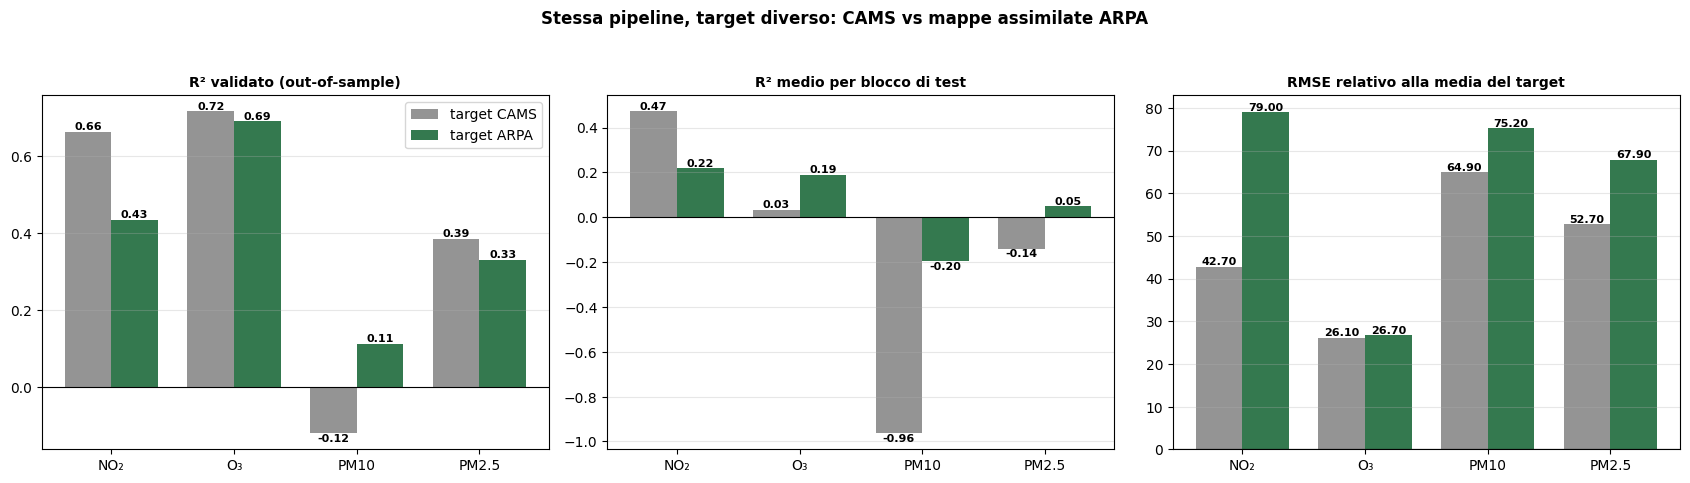

In [8]:
if len(DISPONIBILI) == 2:
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
    x = np.arange(len(ORDINE))
    larghezza = 0.38
    coppie = [('R² validazione', 'R² validato (out-of-sample)', None),
              ('R² medio per fold', 'R² medio per blocco di test', None),
              ('RMSE / media [%]', 'RMSE relativo alla media del target', '%')]
    for ax, (campo, titolo, unita) in zip(axes, coppie):
        vc = TABELLE['CAMS'][campo].values
        va = TABELLE['ARPA'][campo].values
        ax.bar(x - larghezza / 2, vc, larghezza, label='target CAMS',
               color='#888888', alpha=0.9)
        ax.bar(x + larghezza / 2, va, larghezza, label='target ARPA',
               color='#1E6B3C', alpha=0.9)
        ax.axhline(0, color='black', lw=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels([ETICHETTA_INQ[i] for i in ORDINE])
        ax.set_title(titolo, fontsize=10, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        for i, (a, b) in enumerate(zip(vc, va)):
            ax.text(i - larghezza / 2, a, f'{a:.2f}', ha='center',
                    va='bottom' if a >= 0 else 'top', fontsize=8, fontweight='bold')
            ax.text(i + larghezza / 2, b, f'{b:.2f}', ha='center',
                    va='bottom' if b >= 0 else 'top', fontsize=8, fontweight='bold')
    axes[0].legend()
    fig.suptitle('Stessa pipeline, target diverso: CAMS vs mappe assimilate ARPA',
                 fontweight='bold', y=1.04)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'confronto_metriche_cams_arpa.png', dpi=150, bbox_inches='tight')
    plt.show()

In [9]:
# ── Numeri chiave ricalcolati dai risultati correnti ────────────────────────
# L'interpretazione della sezione 7 fa riferimento a questi valori: se le pipeline
# vengono rieseguite con dati diversi, questa cella mostra i numeri aggiornati.
if len(DISPONIBILI) == 2:
    print('Δ R² validato (ARPA − CAMS), per inquinante:')
    for _, r in conf.iterrows():
        verso = 'ARPA meglio' if r['Δ R² (ARPA − CAMS)'] > 0 else 'CAMS meglio'
        print(f"  {r['Inquinante']:6s}: CAMS {r['R² validazione — CAMS']:+.3f}  "
              f"ARPA {r['R² validazione — ARPA']:+.3f}  "
              f"Δ {r['Δ R² (ARPA − CAMS)']:+.3f}   ({verso})")

    print('\nContributo di Sentinel-5P (ΔR² rispetto al modello solo-ERA5):')
    for fam in ['CAMS', 'ARPA']:
        v = RIS[fam]['equazioni'].set_index('Inquinante')['delta_R2_da_S5P']
        print(f"  {fam}: " + '  '.join(f'{i} {v.loc[i]:+.3f}' for i in ORDINE))

    print('\nDivario R² aggregato − R² medio per fold (quanto pesa il livello stagionale):')
    for fam in ['CAMS', 'ARPA']:
        t = TABELLE[fam]
        d = (t['R² validazione'] - t['R² medio per fold'])
        print(f"  {fam}: " + '  '.join(f'{i} {v:+.3f}' for i, v in zip(ORDINE, d)))

Δ R² validato (ARPA − CAMS), per inquinante:
  NO₂   : CAMS +0.664  ARPA +0.435  Δ -0.229   (CAMS meglio)
  O₃    : CAMS +0.717  ARPA +0.691  Δ -0.026   (CAMS meglio)
  PM10  : CAMS -0.119  ARPA +0.114  Δ +0.233   (ARPA meglio)
  PM2.5 : CAMS +0.386  ARPA +0.332  Δ -0.054   (CAMS meglio)

Contributo di Sentinel-5P (ΔR² rispetto al modello solo-ERA5):
  CAMS: NO2 +0.590  O3 +0.102  PM10 +0.136  PM25 +0.803
  ARPA: NO2 +0.403  O3 +0.075  PM10 +0.128  PM25 +0.404

Divario R² aggregato − R² medio per fold (quanto pesa il livello stagionale):
  CAMS: NO2 +0.192  O3 +0.683  PM10 +0.844  PM25 +0.526
  ARPA: NO2 +0.216  O3 +0.501  PM10 +0.310  PM25 +0.283


## 7. Interpretazione delle principali differenze CAMS–ARPA

> I valori citati sono quelli dell'esecuzione corrente, ricalcolati nella cella precedente.

Poiché **predittori, lag, medie mobili, preprocessing e schema di validazione sono identici**,
ogni differenza fra le due tabelle è attribuibile al solo cambio di target.

### 7.1 NO₂ — il calo più marcato (R² 0.66 → 0.44)

È la differenza più netta. Sul target CAMS il modello spiegava due terzi della varianza, sul
target ARPA meno della metà. La lettura più diretta: una parte di ciò che i predittori
spiegavano su CAMS **era la costruzione interna di CAMS**, non il livello di NO₂ ricostruito
dalle stazioni. CAMS è un modello di chimica-trasporto guidato dalla meteorologia IFS/ECMWF,
la stessa famiglia da cui deriva ERA5: predire CAMS con ERA5 è in parte un esercizio di
auto-consistenza fra prodotti imparentati. Quel vantaggio sparisce quando il target è
assimilato da misure.

Si noti anche il cambio di scala: la media di ARPA NO₂ è circa un terzo di quella CAMS, e il
`RMSE/media` passa da ~43% a ~79%. In termini relativi l'errore quasi raddoppia.

### 7.2 PM10 — l'unico caso in cui ARPA va meglio (R² −0.12 → +0.11)

Controcorrente rispetto agli altri tre. Sul target CAMS l'R² out-of-sample era **negativo**,
cioè il modello faceva peggio della media; sul target ARPA torna positivo, seppur basso. Il
PM10 di CAMS contiene dinamiche (trasporto di polveri, aerosol secondario) che la meteorologia
locale del giorno *t* più un indice satellitare non riescono a inseguire, e l'estrapolazione
stagionale dei primi fold produceva errori superiori alla varianza del target. Le mappe
assimilate, più ancorate alle osservazioni, risultano più prevedibili da questi predittori.
Resta comunque il modello più debole delle due famiglie: R² ~0.11 e bias positivo elevato
(sovrastima sistematica nei blocchi estivi).

### 7.3 O₃ e PM2.5 — sostanzialmente stabili

O₃ perde pochissimo (0.72 → 0.69) e resta il modello migliore in entrambe le famiglie. È
coerente con la fisica: l'ozono è fortemente guidato da radiazione e temperatura, cioè da
variabili ERA5 disponibili al giorno *t* senza lacune, e questo legame vale sia per il modello
CAMS sia per la realtà osservata. Il coefficiente di SSRD è il più importante in entrambe le
equazioni. PM2.5 perde poco (0.39 → 0.33) e mantiene un contributo satellitare rilevante.

### 7.4 Il contributo di Sentinel-5P si riduce ma non sparisce

Il ΔR² rispetto al modello solo-ERA5 resta positivo per tutti e quattro gli inquinanti in
entrambe le famiglie, ma è sistematicamente **più basso sul target ARPA** (es. PM2.5: +0.80 su
CAMS, +0.40 su ARPA). Parte dell'apparente potere predittivo del satellite su CAMS era
anch'essa auto-consistenza fra prodotti modellistici. Il contributo che sopravvive sul target
ARPA è la stima più credibile del valore aggiunto dell'osservazione satellitare.

### 7.5 Un limite comune a entrambe le famiglie

In tutti i modelli l'**R² aggregato è molto più alto dell'R² medio per fold**. Significa che i
modelli colgono soprattutto il **livello stagionale** — distinguono l'inverno dall'estate — molto
meglio della variabilità giorno per giorno dentro una stagione. Vale sia per CAMS sia per ARPA
ed è il limite principale di un modello lineare con predittori prevalentemente stagionali.

### 7.6 Perché il target ARPA è intrinsecamente più difficile

Le mappe ARPA hanno una risoluzione spaziale effettiva circa **4 volte più fine** di CAMS
(~99% di valori distinti fra i punti contro ~25%). Contengono quindi variabilità fra punti
vicini che predittori su cella ERA5 0.25° non possono riprodurre per costruzione: una quota
dell'R² mancante non è un difetto del modello, ma un **tetto strutturale** imposto dalla
risoluzione dei predittori meteorologici.

### In sintesi

I modelli a target CAMS sono **numericamente migliori ma concettualmente meno informativi**:
misurano quanta parte di CAMS è ricostruibile dalla meteorologia che CAMS stesso usa. I modelli
a target ARPA rispondono alla domanda più utile — *quanto si riesce a stimare il livello di
inquinamento ricostruito dalle misure* — e i loro valori, più bassi, sono la stima realistica.
Per un uso operativo il riferimento sono i modelli ARPA; i modelli CAMS restano utili come
termine di paragone e come diagnosi di quanto pesi l'accoppiamento ERA5–CAMS.

In [ ]:
# ── Esportazione ─────────────────────────────────────────────────────────────
print('File salvati in', OUT_DIR.resolve())
for f in sorted(OUT_DIR.iterdir()):
    print('  ', f.name)